# Klasifikasi Batik - Metode Hybrid (GLCM + CNN MobileNetV2)

Notebook ini mengimplementasikan metode yang menggabungkan fitur tekstur (GLCM) dan fitur visual otomatis dari CNN (*Transfer Learning* menggunakan MobileNetV2). Berdasarkan riset literatur, penggabungan kedua jenis ekstraksi fitur ini terbukti efektif dalam membedakan kelas motif batik yang memiliki kemiripan tinggi.

Pembaharuan: Pipeline ini telah dilengkapi dengan teknik **CLAHE** untuk meratakan pencahayaan bayangan kain, dan **Zero-Padding** untuk mencegah distorsi bentuk geometris saat merubah resolusi citra.


In [8]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import time

from skimage.feature import graycomatrix, graycoprops

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import seaborn as sns


## 1. Konfigurasi Path dan Parameter

Pastikan struktur folder `dataset/train` dan `dataset/test` sudah sesuai, di mana setiap subfolder mewakili satu kelas motif batik.


In [9]:
TRAIN_DIR = 'dataset/train'
TEST_DIR = 'dataset/test'

IMG_SIZE = (224, 224)


## 2. Definisi Fungsi Preprocessing (CLAHE & Zero-Padding)

Kita mendefinisikan fungsi khusus untuk menangani masalah pencahayaan (silau/bayangan lipatan kain) dan distorsi bentuk motif (gepeng) akibat *resizing* paksa.


In [10]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    
    limg = cv2.merge((cl, a, b))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
    return final_img

def apply_zero_padding(img, target_size=(224, 224)):
    old_size = img.shape[:2] # height, width
    ratio = min(target_size[0]/old_size[0], target_size[1]/old_size[1])
    new_size = tuple([int(x*ratio) for x in old_size])
    
    img_resized = cv2.resize(img, (new_size[1], new_size[0]))
    
    delta_w = target_size[1] - new_size[1]
    delta_h = target_size[0] - new_size[0]
    top, bottom = delta_h//2, delta_h-(delta_h//2)
    left, right = delta_w//2, delta_w-(delta_w//2)
    
    color = [0, 0, 0]
    new_img = cv2.copyMakeBorder(img_resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
    return new_img


## 3. Visualisasi Tahapan Preprocessing (Sample)

Mari kita lihat bagaimana bentuk gambar pada setiap tahapan preprocessing yang baru kita buat.


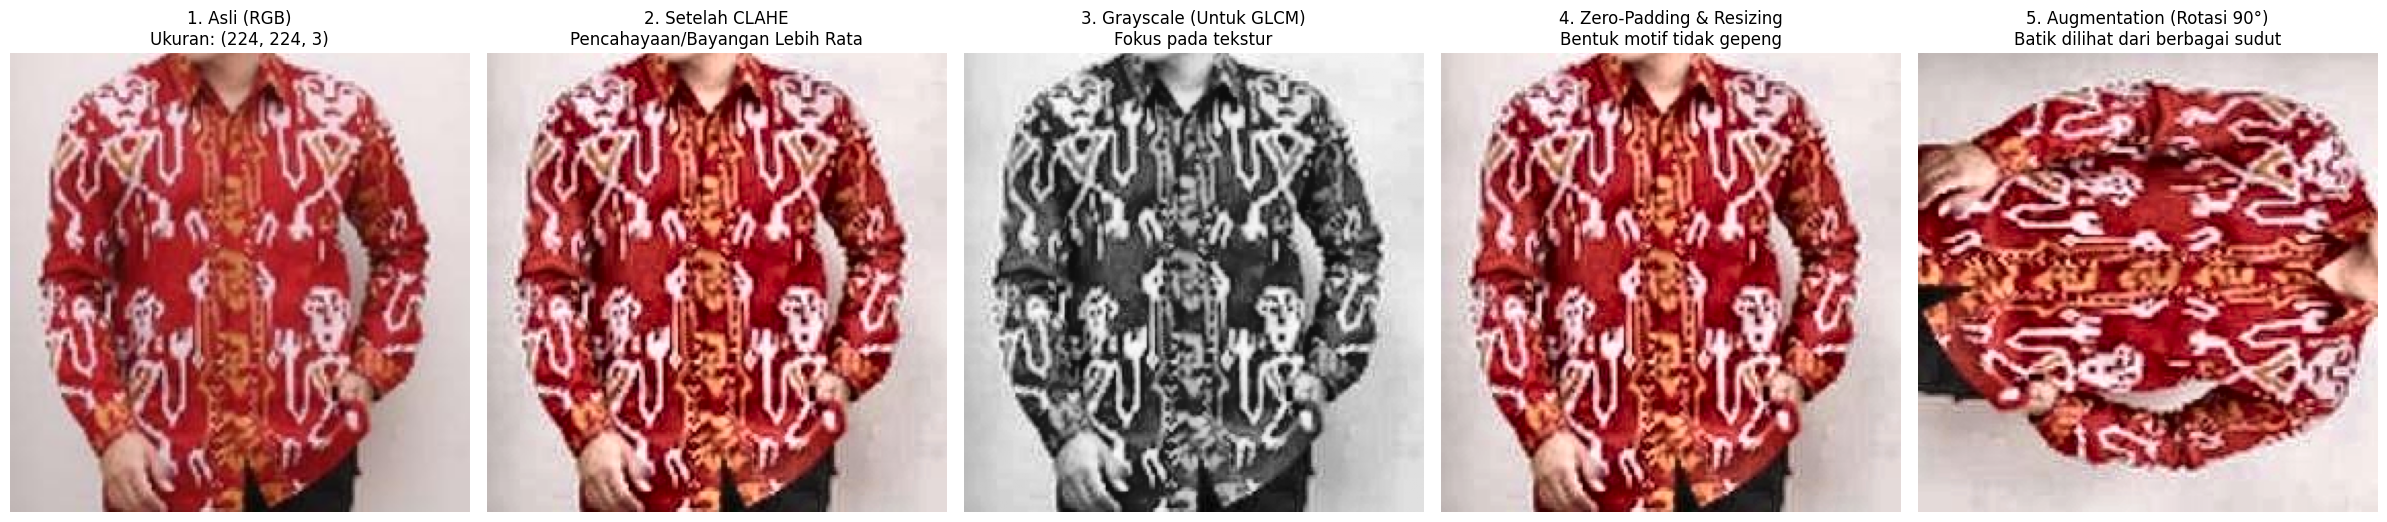

In [11]:
import random

sample_class = random.choice(os.listdir(TRAIN_DIR))
sample_dir = os.path.join(TRAIN_DIR, sample_class)
valid_images = [f for f in os.listdir(sample_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
sample_img_name = random.choice(valid_images)
sample_img_path = os.path.join(sample_dir, sample_img_name)

plt.figure(figsize=(24, 5))

img_original = cv2.imread(sample_img_path)
img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

plt.subplot(1, 5, 1)
plt.imshow(img_original_rgb)
plt.title(f"1. Asli (RGB)\nUkuran: {img_original.shape}")
plt.axis('off')

img_clahe = apply_clahe(img_original)
img_clahe_rgb = cv2.cvtColor(img_clahe, cv2.COLOR_BGR2RGB)

plt.subplot(1, 5, 2)
plt.imshow(img_clahe_rgb)
plt.title(f"2. Setelah CLAHE\nPencahayaan/Bayangan Lebih Rata")
plt.axis('off')

img_gray = cv2.cvtColor(img_clahe, cv2.COLOR_BGR2GRAY)

plt.subplot(1, 5, 3)
plt.imshow(img_gray, cmap='gray')
plt.title(f"3. Grayscale (Untuk GLCM)\nFokus pada tekstur")
plt.axis('off')

img_padded = apply_zero_padding(img_clahe_rgb, IMG_SIZE)

plt.subplot(1, 5, 4)
plt.imshow(img_padded)
plt.title(f"4. Zero-Padding & Resizing\nBentuk motif tidak gepeng")
plt.axis('off')

img_rotated = cv2.rotate(img_padded, cv2.ROTATE_90_CLOCKWISE)

plt.subplot(1, 5, 5)
plt.imshow(img_rotated)
plt.title(f"5. Augmentation (Rotasi 90°)\nBatik dilihat dari berbagai sudut")
plt.axis('off')

plt.tight_layout()
plt.show()


## 4. Inisialisasi Model CNN sebagai Feature Extractor

Kita menggunakan **MobileNetV2** yang sangat ringan dan akurat. Parameter `include_top=False` berarti kita menghilangkan lapisan klasifikasi akhir bawaannya.


In [12]:
base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))

base_model.trainable = False

## 5. Definisi Fungsi Ekstraksi Fitur

Fungsi ekstraksi kini mengadopsi hasil dari gambar yang telah dibersihkan menggunakan CLAHE dan Zero-Padding.


In [13]:
def extract_glcm_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    distances = [1]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    glcm = graycomatrix(gray, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)
    
    contrast = graycoprops(glcm, 'contrast').mean()
    dissimilarity = graycoprops(glcm, 'dissimilarity').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()
    energy = graycoprops(glcm, 'energy').mean()
    correlation = graycoprops(glcm, 'correlation').mean()
    ASM = graycoprops(glcm, 'ASM').mean()
    
    return [contrast, dissimilarity, homogeneity, energy, correlation, ASM]

def extract_cnn_features(img, model):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    img_padded = apply_zero_padding(img_rgb, target_size=IMG_SIZE)
    
    img_array = img_to_array(img_padded)
    img_array = np.expand_dims(img_array, axis=0)
    
    img_array = preprocess_input(img_array)
    
    features = model.predict(img_array, verbose=0)
    
    return features.flatten()


## 6. Proses Ekstraksi & Data Augmentation

Pada data **Training**, kita akan mengekstrak fitur dari gambar CLAHE dan 3 variasi rotasi (90°, 180°, 270°). Ini berarti jumlah data latih kita akan meningkat **4x lipat**. Pada data **Testing**, rotasi tidak diterapkan.


In [ ]:
def process_dataset(directory, cnn_model, augment_rotation=False):
    features_combined = []
    labels = []
    
    classes = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])
    
    for class_name in tqdm(classes, desc=f"Processing {directory}"):
        class_dir = os.path.join(directory, class_name)
        
        for img_name in os.listdir(class_dir):
            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
                
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path)
            
            if img is None:
                continue
            
            # --- 1. PREPROCESSING CLAHE ---
            img_clahe = apply_clahe(img)
                
            # Daftar rotasi (Asli = None)
            rotations = [None]
            
            if augment_rotation:
                rotations.extend([
                    cv2.ROTATE_90_CLOCKWISE,
                    cv2.ROTATE_180,
                    cv2.ROTATE_90_COUNTERCLOCKWISE
                ])
                
            for rot in rotations:
                try:
                    if rot is not None:
                        img_processed = cv2.rotate(img_clahe, rot)
                    else:
                        img_processed = img_clahe
                        
                    glcm_feats = extract_glcm_features(img_processed)
                    cnn_feats = extract_cnn_features(img_processed, cnn_model)
                    
                    combined = np.hstack((glcm_feats, cnn_feats))
                    
                    features_combined.append(combined)
                    labels.append(class_name)
                    
                except Exception as e:
                    print(f"Error memproses variasi rotasi pada {img_path}: {e}")
                    
    return np.array(features_combined), np.array(labels)

X_train, y_train_raw = process_dataset(TRAIN_DIR, base_model, augment_rotation=True)

X_test, y_test_raw = process_dataset(TEST_DIR, base_model, augment_rotation=False)

print(f"\nJumlah data train setelah augmentasi: {X_train.shape[0]}")
print(f"Jumlah data test: {X_test.shape[0]}")
print(f"Dimensi vektor fitur: {X_train.shape[1]}")


Processing dataset/train:   0%|          | 0/20 [00:00<?, ?it/s]

Processing dataset/test:  75%|███████▌  | 15/20 [01:16<00:24,  4.92s/it]

## 7. Preprocessing Fitur (Label Encoding, Scaling, & PCA)

Fitur GLCM (skala bisa sangat besar) dan fitur CNN (berkisar -1 s/d 1) diseragamkan rentangnya. Karena dimensinya sangat besar (1286 fitur), kita menggunakan **PCA (Principal Component Analysis)** untuk mereduksi dimensi dengan mempertahankan 95% varians informasi, yang akan mempercepat pelatihan dan mengurangi risiko *overfitting*.


In [ ]:
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Dimensi fitur SEBELUM PCA: {X_train_scaled.shape[1]}")
print(f"Dimensi fitur SETELAH PCA: {X_train_pca.shape[1]}")

NameError: name 'y_train_raw' is not defined

## 8. Pelatihan Model Final & Pengukuran Waktu

Kita menggunakan parameter terbaik yang telah didapatkan dari proses eksperimen *Hyperparameter Tuning* sebelumnya. Parameter tersebut langsung dimasukkan ke dalam model (hardcoded) agar proses run notebook utama ini lebih cepat dan fokus pada evaluasi akhir.


In [ ]:
models = {
    "SVM": {
        "model": SVC(C=10, kernel='rbf', probability=True, random_state=42),
        "param_info": "C=10, kernel='rbf'"
    },
    "K-Nearest Neighbors": {
        "model": KNeighborsClassifier(n_neighbors=3, weights='distance'),
        "param_info": "n_neighbors=3, weights='distance'"
    },
    "Random Forest": {
        "model": RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42),
        "param_info": "n_estimators=100, max_depth=20"
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(max_depth=None, random_state=42),
        "param_info": "max_depth=None"
    },
    "Dense Neural Network (MLP)": {
        "model": MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=42),
        "param_info": "hidden_layers=(256, 128), max_iter=500"
    }
}

results = {}

for name, info in models.items():
    print(f"Melatih model {name}...")
    model = info["model"]
    
    start_train = time.time()
    model.fit(X_train_pca, y_train)
    end_train = time.time()
    
    start_pred = time.time()
    y_pred = model.predict(X_test_pca)
    end_pred = time.time()
    
    acc = accuracy_score(y_test, y_pred)
    train_time = end_train - start_train
    pred_time = end_pred - start_pred
    
    results[name] = {
        'accuracy': acc,
        'predictions': y_pred,
        'train_time': train_time,
        'pred_time': pred_time,
        'param_info': info["param_info"]
    }
    
    print(f"-> Waktu Latih: {train_time:.4f} detik | Waktu Prediksi: {pred_time:.4f} detik")
    print(f"-> Selesai! Akurasi: {acc * 100:.2f}%\n")


NameError: name 'SVC' is not defined

## 9. Evaluasi Semua Model

Menampilkan perbandingan komprehensif metrik evaluasi (termasuk waktu komputasi) untuk setiap model yang telah dilatih dengan parameter terbaik.


TABEL PERBANDINGAN MODEL KLASIFIKASI (PARAMETER TERBAIK)


,Model,Akurasi (%),Waktu Latih (detik),Waktu Prediksi (detik),Parameter Terbaik
0,SVM,95.94,52.5538,1.0412,"C=10, kernel='rbf'"
1,K-Nearest Neighbors,93.75,0.0583,0.1437,"n_neighbors=3, weights='distance'"
2,Random Forest,91.25,17.2598,0.0165,"n_estimators=100, max_depth=20"
3,Decision Tree,56.25,7.0685,0.0020,max_depth=None
4,Dense Neural Network (MLP),95.62,22.1616,0.0045,"hidden_layers=(256, 128), max_iter=500"





EVALUASI MODEL: SVM

--- Classification Report (SVM) ---
                            precision    recall  f1-score   support

           Aceh_Pintu_Aceh       1.00      0.88      0.93        16
               Bali_Barong       1.00      1.00      1.00        16
                Bali_Merak       1.00      1.00      1.00        16
           DKI_Ondel_Ondel       0.87      0.81      0.84        16
     JawaBarat_Megamendung       1.00      1.00      1.00        16
           JawaTimur_Pring       1.00      0.94      0.97        16
          Kalimantan_Dayak       1.00      1.00      1.00        16
             Lampung_Gajah       0.89      1.00      0.94        16
        Madura_Mataketeran       1.00      0.88      0.93        16
               Maluku_Pala       1.00      1.00      1.00        16
               NTB_Lumbung       1.00      0.88      0.93        16
               Papua_Asmat       1.00      1.00      1.00        16
         Papua_Cendrawasih       0.89      1.00      0.

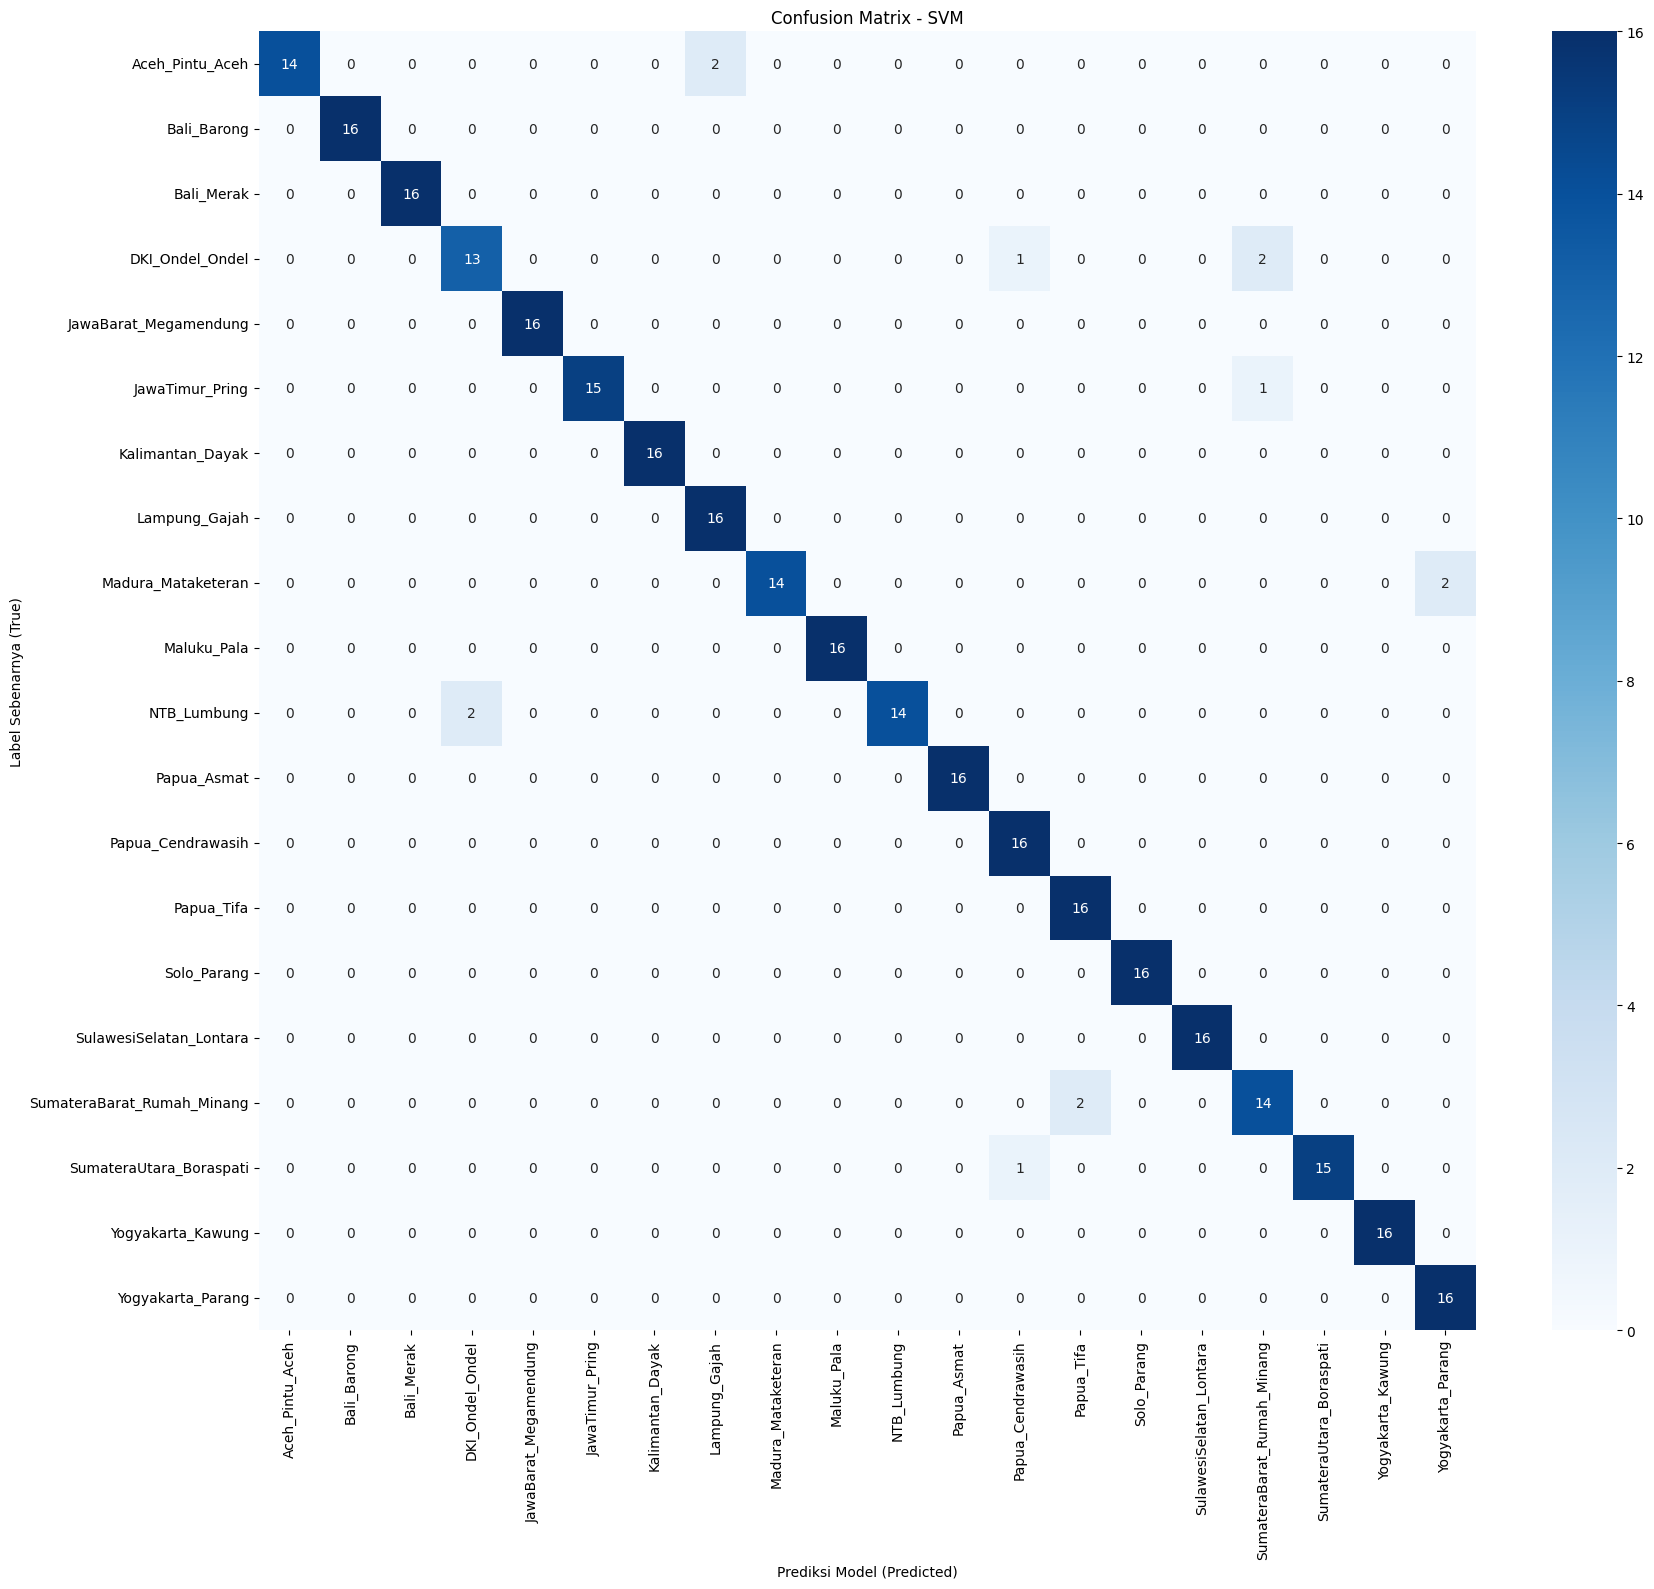


EVALUASI MODEL: K-Nearest Neighbors

--- Classification Report (K-Nearest Neighbors) ---
                            precision    recall  f1-score   support

           Aceh_Pintu_Aceh       0.92      0.75      0.83        16
               Bali_Barong       1.00      1.00      1.00        16
                Bali_Merak       1.00      1.00      1.00        16
           DKI_Ondel_Ondel       0.93      0.88      0.90        16
     JawaBarat_Megamendung       1.00      1.00      1.00        16
           JawaTimur_Pring       1.00      0.88      0.93        16
          Kalimantan_Dayak       1.00      1.00      1.00        16
             Lampung_Gajah       0.88      0.94      0.91        16
        Madura_Mataketeran       0.93      0.88      0.90        16
               Maluku_Pala       0.84      1.00      0.91        16
               NTB_Lumbung       1.00      0.88      0.93        16
               Papua_Asmat       0.94      1.00      0.97        16
         Papua_Cendrawasi

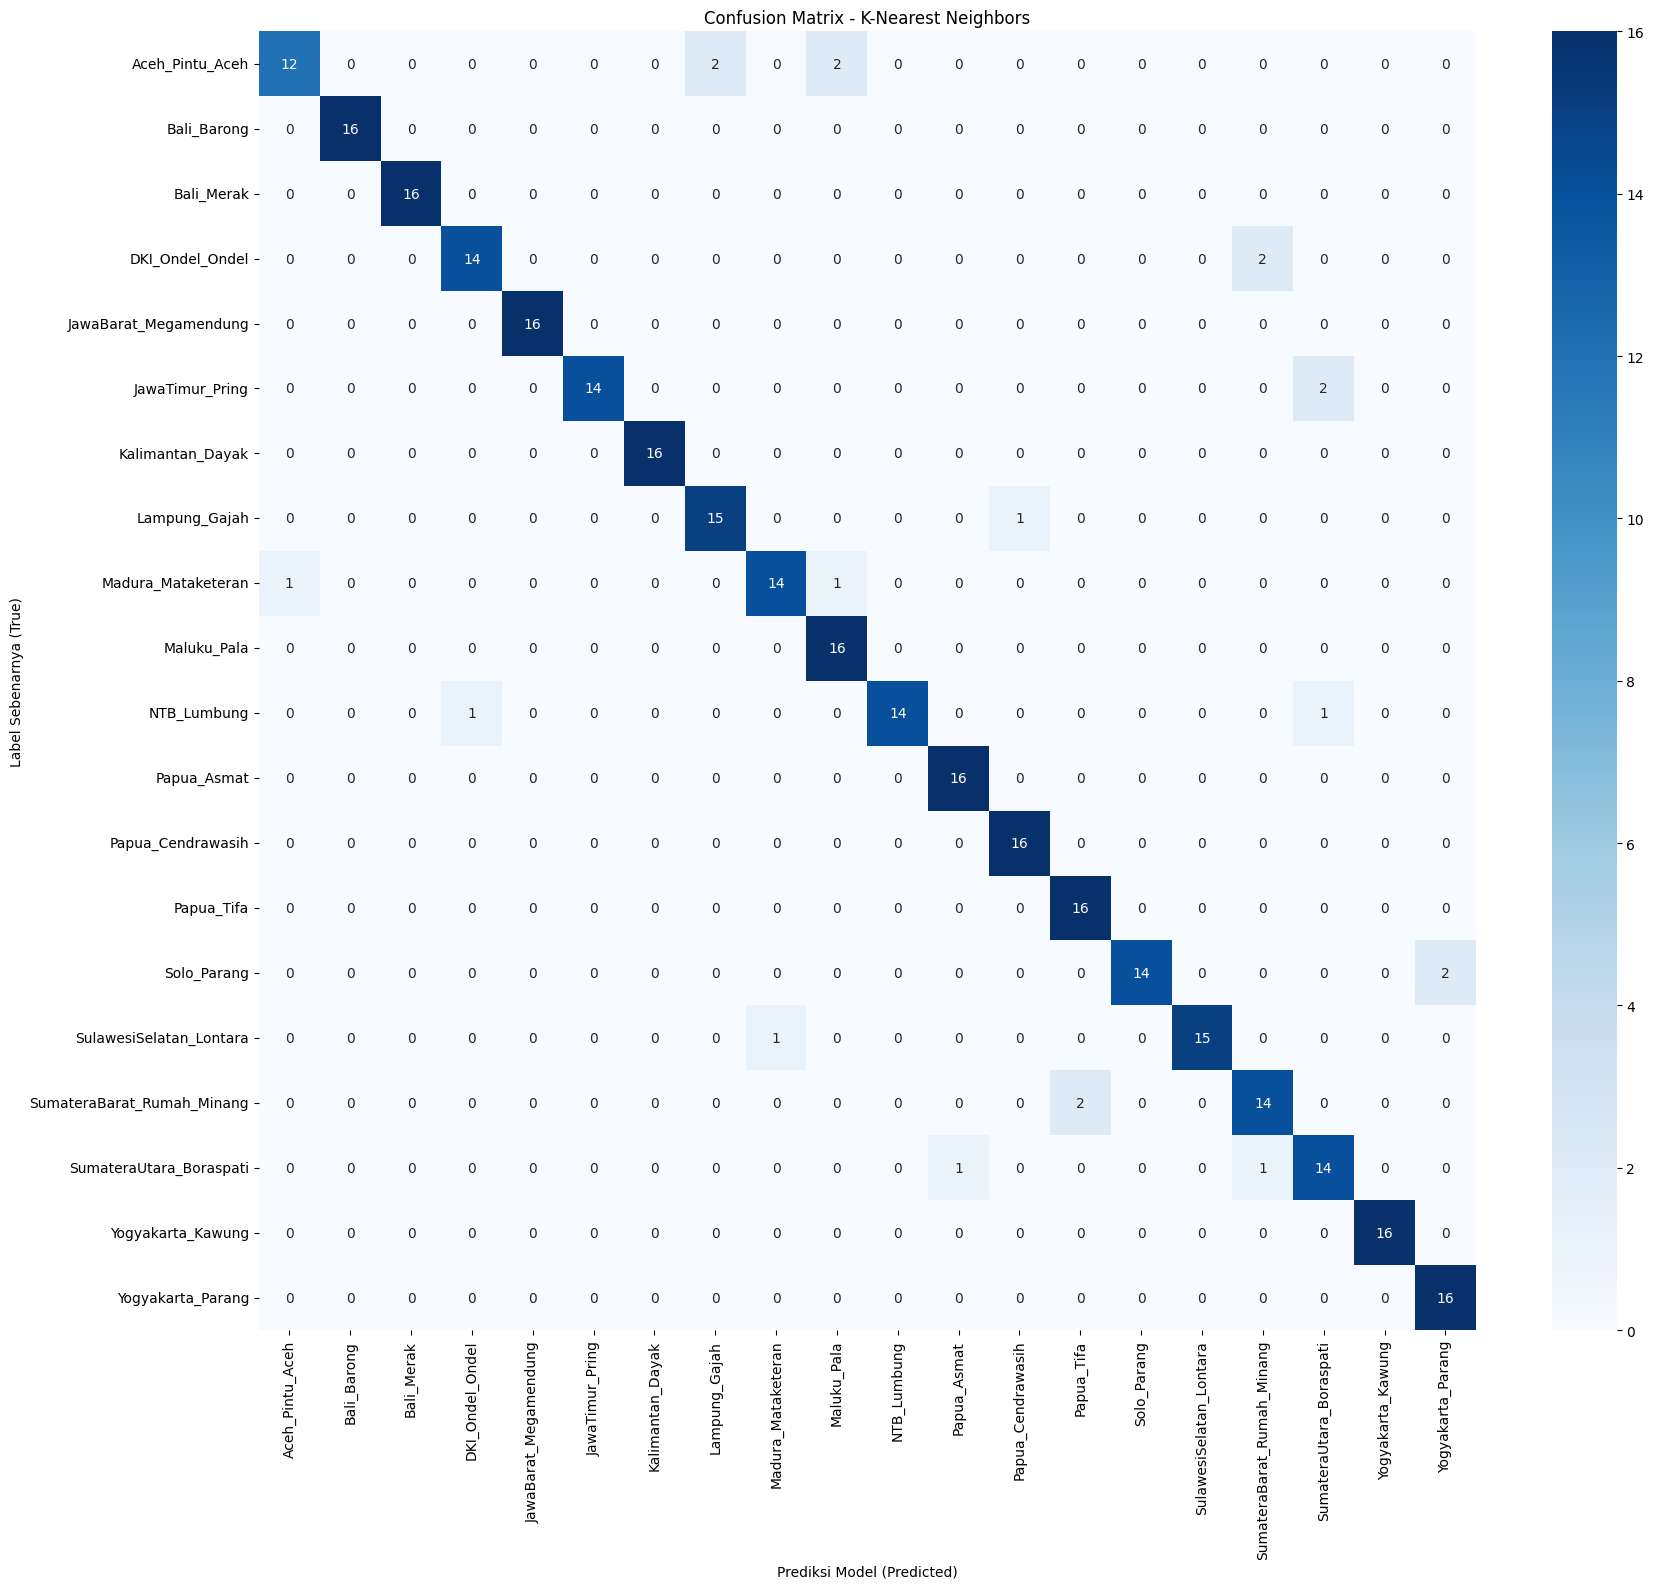


EVALUASI MODEL: Random Forest

--- Classification Report (Random Forest) ---
                            precision    recall  f1-score   support

           Aceh_Pintu_Aceh       0.81      0.81      0.81        16
               Bali_Barong       0.88      0.94      0.91        16
                Bali_Merak       0.94      0.94      0.94        16
           DKI_Ondel_Ondel       0.75      0.75      0.75        16
     JawaBarat_Megamendung       0.88      0.94      0.91        16
           JawaTimur_Pring       0.87      0.81      0.84        16
          Kalimantan_Dayak       0.94      1.00      0.97        16
             Lampung_Gajah       0.76      1.00      0.86        16
        Madura_Mataketeran       1.00      0.88      0.93        16
               Maluku_Pala       1.00      0.81      0.90        16
               NTB_Lumbung       1.00      0.88      0.93        16
               Papua_Asmat       1.00      0.94      0.97        16
         Papua_Cendrawasih       1.00

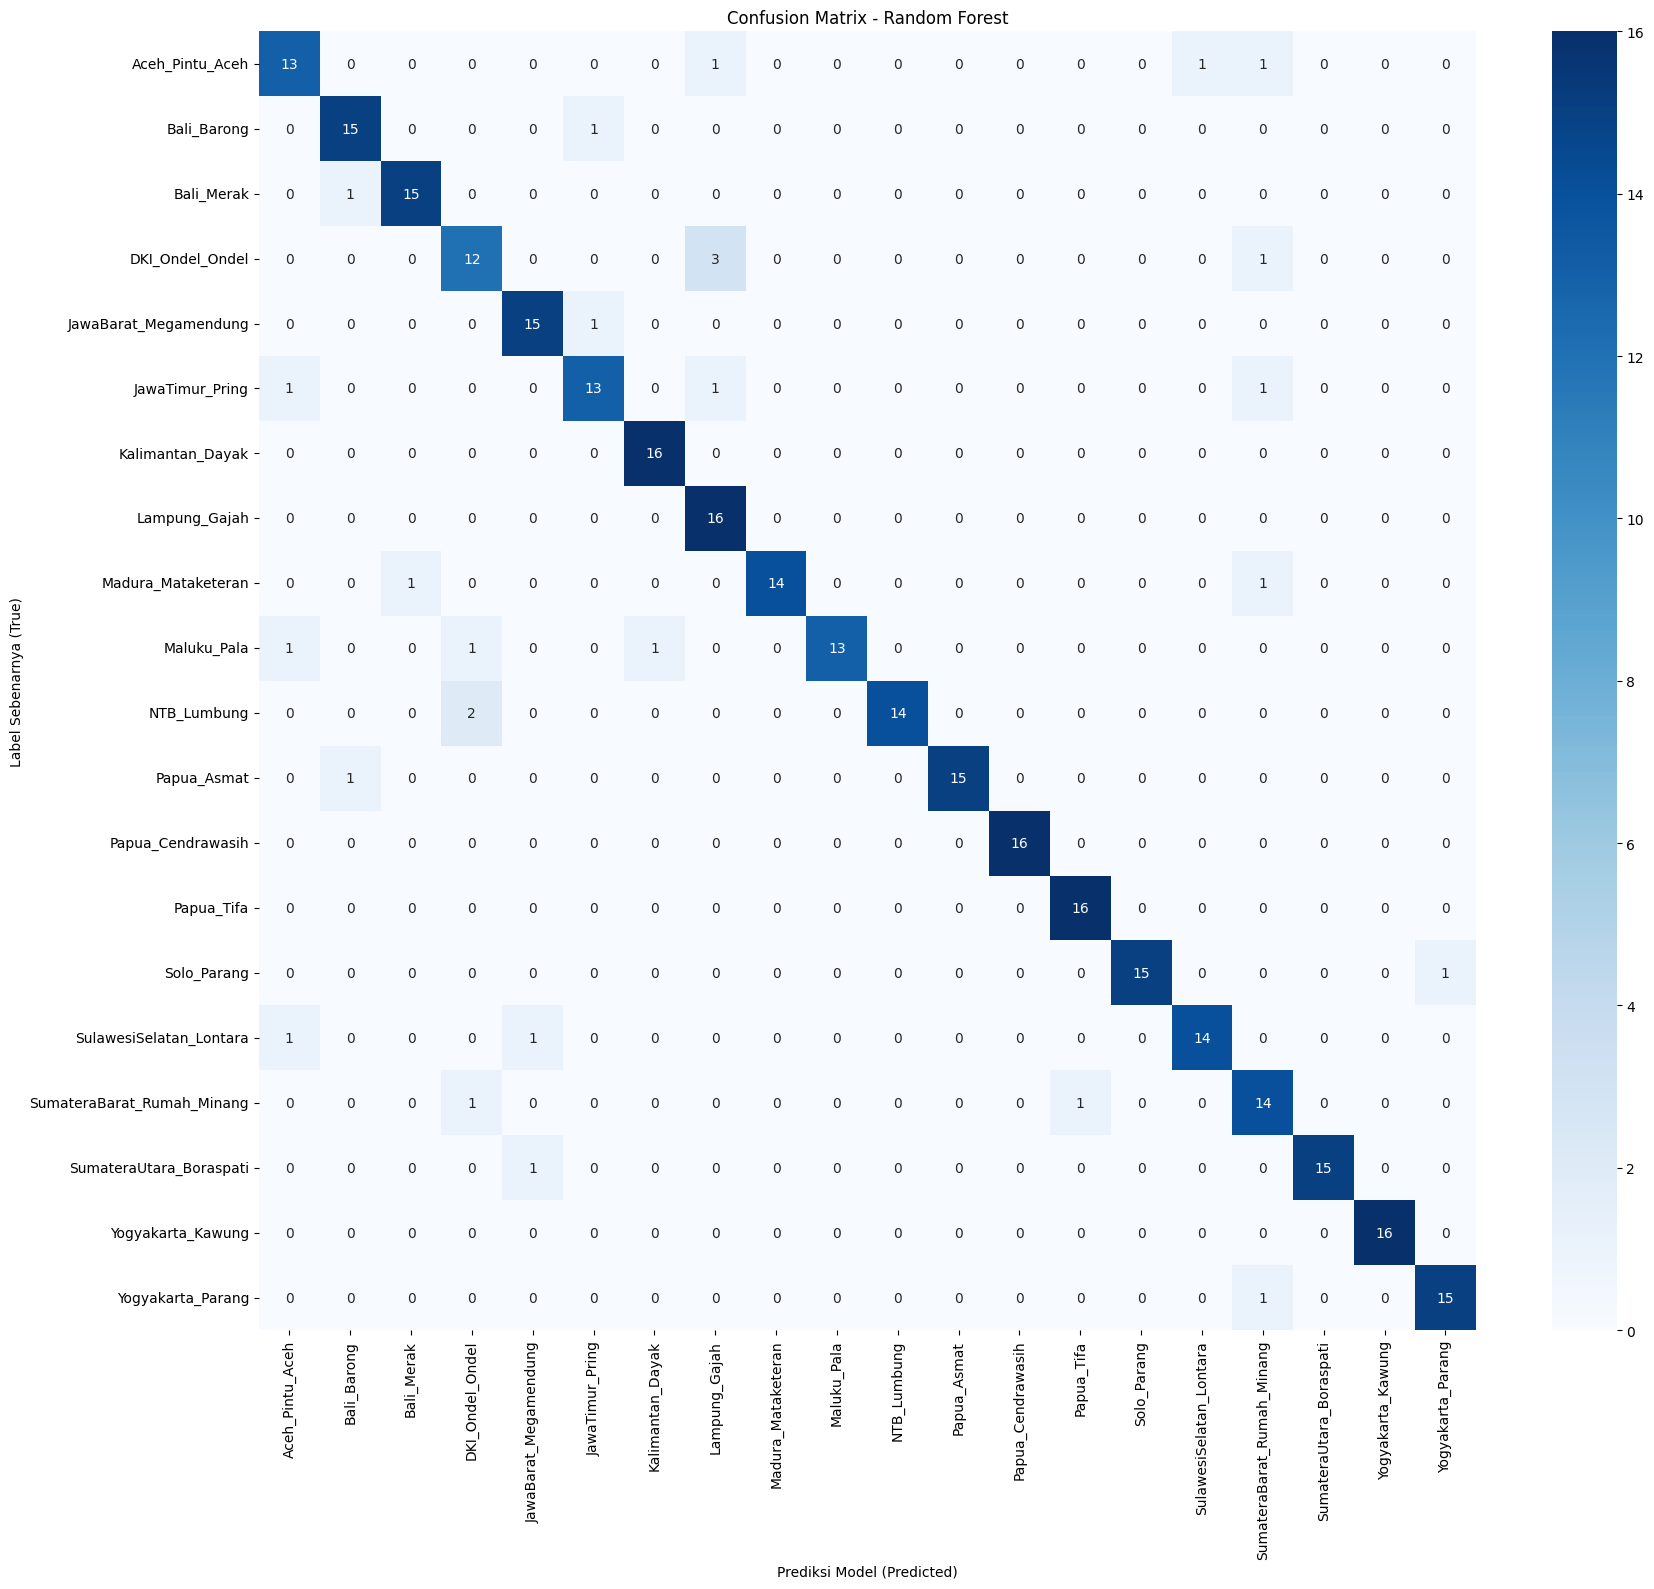


EVALUASI MODEL: Decision Tree

--- Classification Report (Decision Tree) ---
                            precision    recall  f1-score   support

           Aceh_Pintu_Aceh       0.22      0.25      0.24        16
               Bali_Barong       0.58      0.69      0.63        16
                Bali_Merak       0.81      0.81      0.81        16
           DKI_Ondel_Ondel       0.70      0.44      0.54        16
     JawaBarat_Megamendung       0.87      0.81      0.84        16
           JawaTimur_Pring       0.53      0.50      0.52        16
          Kalimantan_Dayak       0.84      1.00      0.91        16
             Lampung_Gajah       0.42      0.50      0.46        16
        Madura_Mataketeran       0.67      0.50      0.57        16
               Maluku_Pala       0.60      0.56      0.58        16
               NTB_Lumbung       0.54      0.44      0.48        16
               Papua_Asmat       0.29      0.12      0.17        16
         Papua_Cendrawasih       0.69

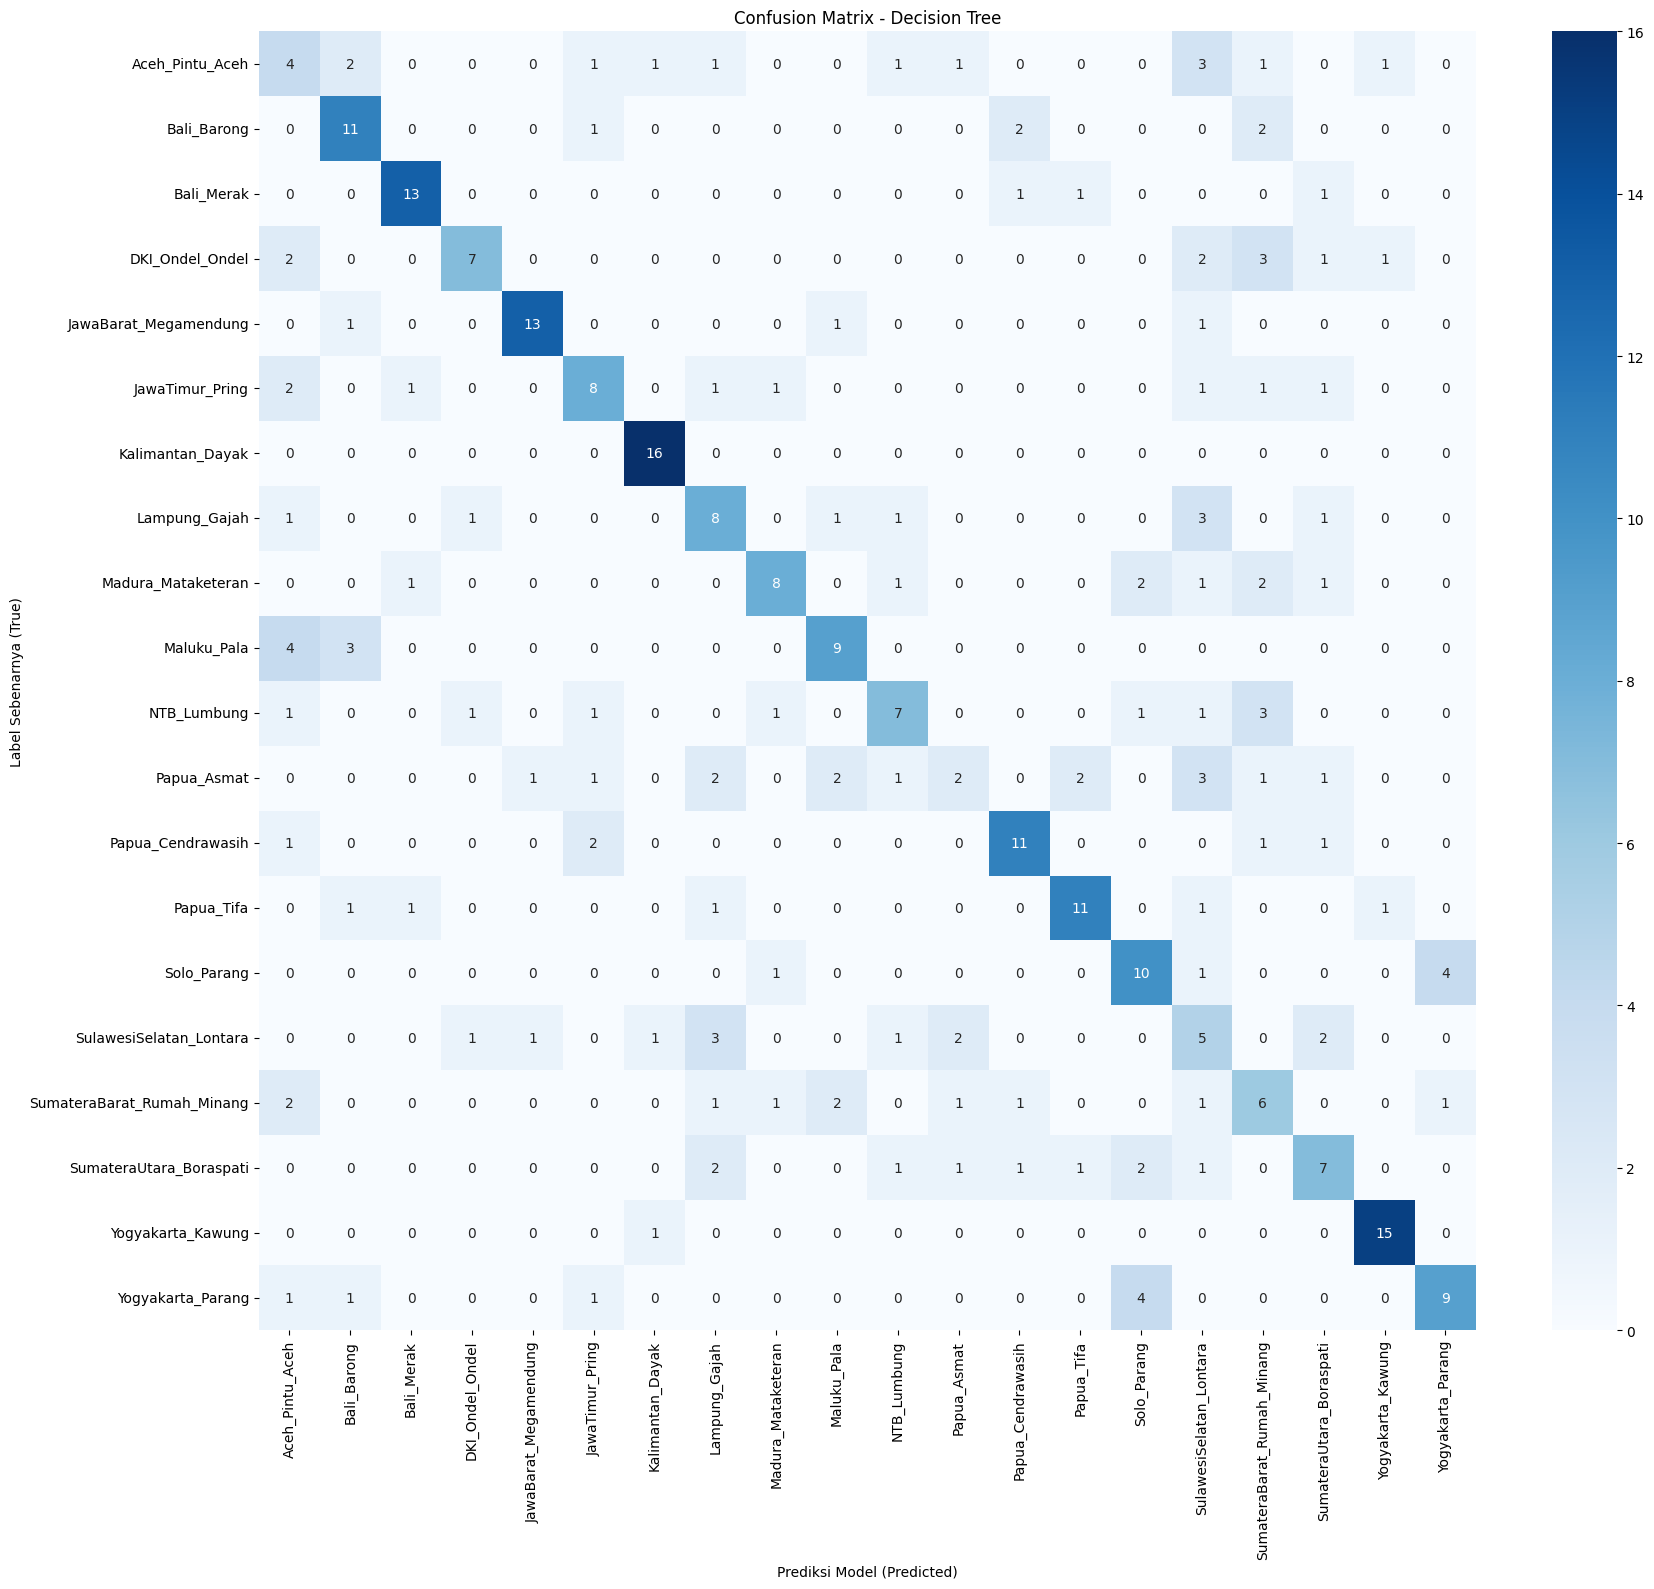


EVALUASI MODEL: Dense Neural Network (MLP)

--- Classification Report (Dense Neural Network (MLP)) ---
                            precision    recall  f1-score   support

           Aceh_Pintu_Aceh       1.00      0.88      0.93        16
               Bali_Barong       1.00      1.00      1.00        16
                Bali_Merak       1.00      1.00      1.00        16
           DKI_Ondel_Ondel       0.93      0.81      0.87        16
     JawaBarat_Megamendung       1.00      1.00      1.00        16
           JawaTimur_Pring       1.00      0.88      0.93        16
          Kalimantan_Dayak       1.00      1.00      1.00        16
             Lampung_Gajah       1.00      1.00      1.00        16
        Madura_Mataketeran       1.00      0.88      0.93        16
               Maluku_Pala       1.00      0.88      0.93        16
               NTB_Lumbung       0.83      0.94      0.88        16
               Papua_Asmat       1.00      1.00      1.00        16
         Pa

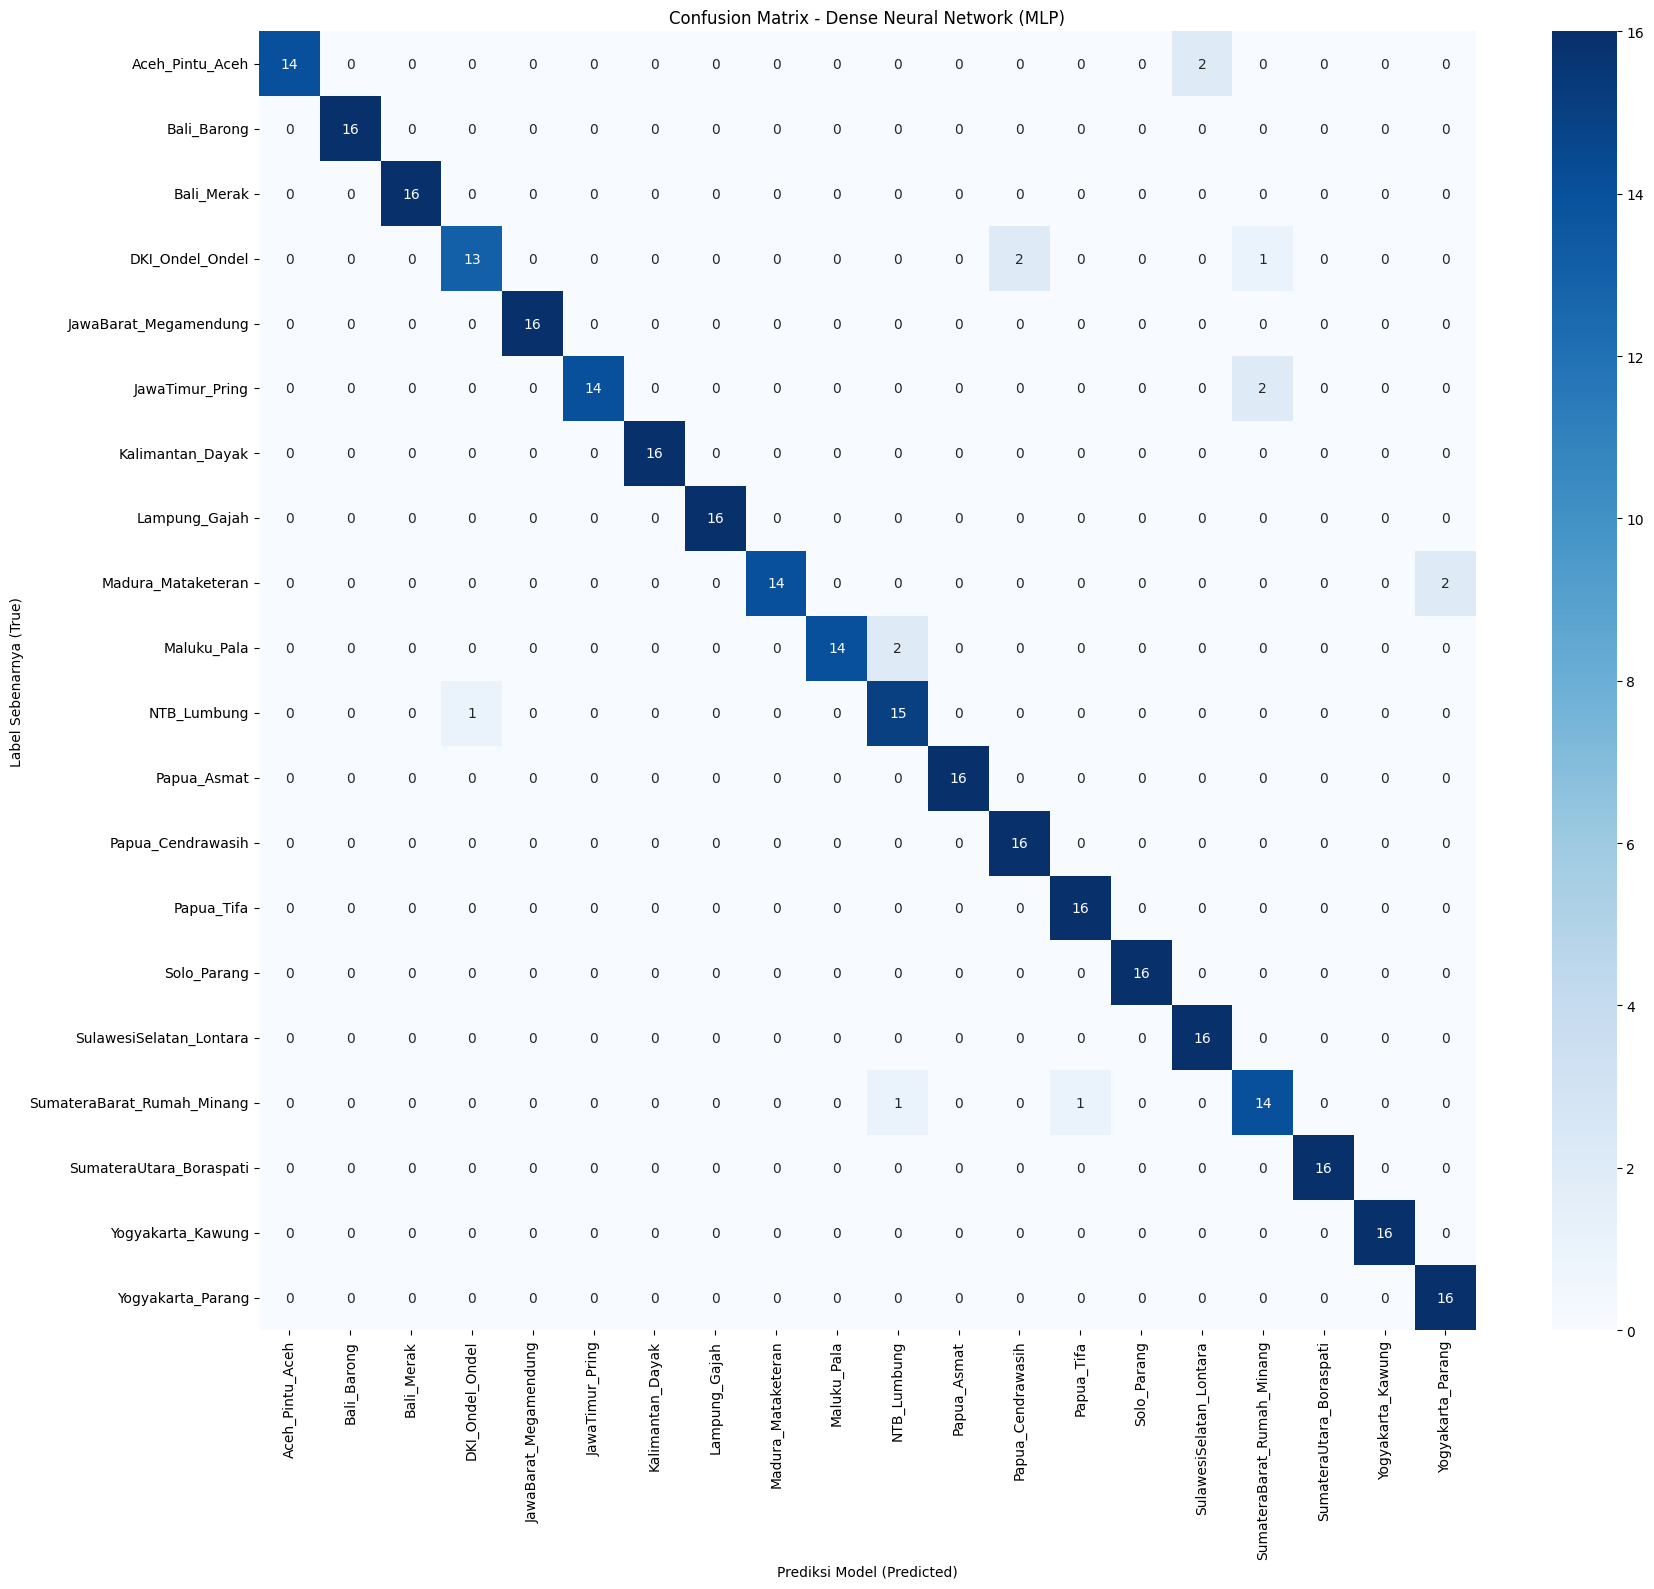

In [ ]:
comparison_data = []
for name, res in results.items():
    comparison_data.append({
        "Model": name,
        "Akurasi (%)": round(res['accuracy'] * 100, 2),
        "Waktu Latih (detik)": round(res['train_time'], 4),
        "Waktu Prediksi (detik)": round(res['pred_time'], 4),
        "Parameter Terbaik": res['param_info']
    })

df_compare = pd.DataFrame(comparison_data)
print("=========================================================================================")
print("TABEL PERBANDINGAN MODEL KLASIFIKASI BATIK HYBRID (GLCM + CNN)")
print("=========================================================================================")
display(df_compare)
print("\n")

for name, res in results.items():
    print(f"\n{'='*50}")
    print(f"EVALUASI MODEL: {name}")
    print(f"{'='*50}")
    
    print(f"\n--- Classification Report ({name}) ---")
    print(classification_report(y_test, res['predictions'], target_names=le.classes_))
    
    cm = confusion_matrix(y_test, res['predictions'])
    
    plt.figure(figsize=(18, 16))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Label Sebenarnya (True)')
    plt.xlabel('Prediksi Model (Predicted)')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


## 10. Uji Coba Model dengan Citra Baru

Bagian ini memungkinkan Anda untuk menguji model dengan gambar batik di luar dataset. Fungsi ini akan secara otomatis melakukan tahapan *preprocessing*, ekstraksi fitur hybrid, reduksi PCA, dan memprediksi hasilnya beserta persentase kecocokan (*Confidence Score*) untuk 3 tebakan teratas.



[SVM] Sedang memproses gambar: dataset/test\JawaTimur_Pring\60005.jpg


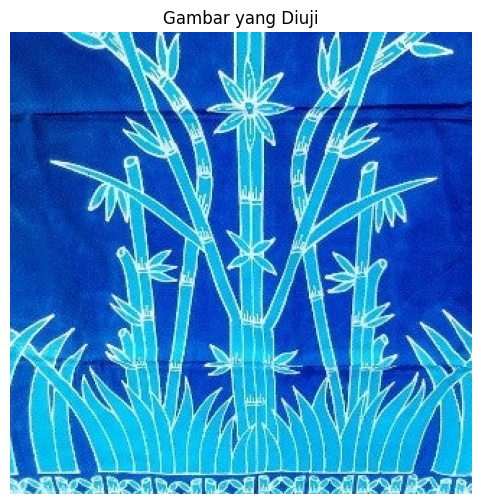

HASIL PREDIKSI (TOP 3):
1. JawaTimur_Pring                : 92.02%
2. NTB_Lumbung                    : 1.11%
3. SumateraBarat_Rumah_Minang     : 1.05%

KESIMPULAN: Model meyakini ini adalah batik motif **JawaTimur_Pring**.


In [ ]:
def prediksi_batik_baru(image_path, model_pilihan='SVM'):
    print(f"\n[{model_pilihan}] Sedang memproses gambar: {image_path}")
    
    # 1. Baca Gambar
    img = cv2.imread(image_path)
    if img is None:
        print("ERROR: Gambar tidak ditemukan atau path salah!")
        return
        
    # 2. Preprocessing CLAHE & Ekstraksi Fitur Hybrid
    img_clahe = apply_clahe(img)
    glcm_feats = extract_glcm_features(img_clahe)
    cnn_feats = extract_cnn_features(img_clahe, base_model) # Padding otomatis di dalam
    combined_feats = np.hstack((glcm_feats, cnn_feats))
    
    # 3. Preprocessing (Reshape, Scale, PCA)
    # Harus di-reshape ke bentuk matriks 2D (1 baris, n kolom)
    feats_2d = combined_feats.reshape(1, -1)
    feats_scaled = scaler.transform(feats_2d)
    feats_pca = pca.transform(feats_scaled)
    
    # 4. Prediksi menggunakan model yang dipilih
    model = models[model_pilihan]["model"]
    
    # Dapatkan probabilitas (persentase)
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(feats_pca)[0]
    else:
        print("Model ini tidak mendukung probabilitas!")
        return
        
    # 5. Dapatkan Top 3 Prediksi
    # Mengambil indeks 3 nilai probabilitas tertinggi (diurutkan dari terkecil ke terbesar, lalu dibalik)
    top3_idx = probabilities.argsort()[-3:][::-1]
    
    # 6. Tampilkan Hasil (Visualisasi Gambar & Teks)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title("Gambar yang Diuji")
    plt.axis('off')
    plt.show()
    
    print("=========================================")
    print("HASIL PREDIKSI (TOP 3):")
    print("=========================================")
    for i, idx in enumerate(top3_idx):
        nama_kelas = le.classes_[idx]
        persentase = probabilities[idx] * 100
        print(f"{i+1}. {nama_kelas:<30} : {persentase:.2f}%")
        
    # Tebakan Utama
    pred_utama = le.classes_[top3_idx[0]]
    print(f"\nKESIMPULAN: Model meyakini ini adalah batik motif **{pred_utama}**.")

# =========================================================================
# CARA PENGGUNAAN:
# 1. Masukkan path gambar yang ingin dites (contoh mengambil gambar acak dari Data Test)
# 2. Anda bisa mengubah variabel 'gambar_tes' ke path file Anda sendiri, misal: 'C:/Users/foto_batik.jpg'
# =========================================================================

# Mengambil satu sampel acak dari folder Test sebagai simulasi
sample_class_test = random.choice(os.listdir(TEST_DIR))
sample_dir_test = os.path.join(TEST_DIR, sample_class_test)
valid_images_test = [f for f in os.listdir(sample_dir_test) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
gambar_tes = os.path.join(sample_dir_test, random.choice(valid_images_test))

# Anda bisa mengganti modelnya menjadi 'SVM' atau 'Random Forest'
prediksi_batik_baru(gambar_tes, model_pilihan='SVM')
